In [1]:
### 1. Setup and imports

from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
### 2. Foundations from Part A

class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass



@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost


def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [3]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # Return True if state is equal to the goal state.
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        l: List[str] = []

        for move, (x, y) in MOVES.items():
            # Computing the resulting coordinates for the current move
            computed = (x + state[0], y + state[1])

            # Setting bounds to use for check below (Co-ordinates are only valid if it's between
            # zero and the size of the grid, not just non-negative)
            x_in_bounds = 0 <= computed[0] < len(self.grid)
            y_in_bounds = 0 <= computed[1] < len(self.grid[0])

            # Checking for whether it is in bounds and the cell is free
            if x_in_bounds and y_in_bounds and self.grid[computed[0]][computed[1]] == 0:
                l.append(move) # add the action to the list


        return l


    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # Return the next state after applying action to state.
        dr, dc = MOVES[action]
        return state[0] + dr, state[1] + dc

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        return 1



class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, p: Problem, node: Node) -> Iterable[Node]:
        s = node.state

        for a in p.actions(s):
            s_prime = p.result(s, a)
            new_cost = node.path_cost + p.action_cost(s, a, s_prime)
            yield Node(s_prime, node, a, new_cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [4]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

In [5]:
### 3. Weighted Terrain: WeightedGridProblem

class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:

        # Return self.terrain_costs[row][col].
        return self.terrain_costs[next_state[0]][next_state[1]]

In [6]:
### 3.1 Self-Check for WeightedGridProblem


wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


In [7]:
### 4 - 4.1 Heuristic Functions, Admissibility and Consistency on Our Grid

def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    return abs(state[0] - goal[0]) + abs(state[1] - goal[1])



def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    return math.sqrt( math.pow((state[0] - goal[0]), 2) + math.pow((state[1] - goal[1]), 2) )


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0




In [8]:
### 4 - 4.2 Self check for the heuristics


assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


In [9]:
### 5 - The Priority-Queue Frontier


class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

In [10]:
### 6 - The BestFirstSearch Framework

class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
        initial_node = Node(problem.initial_state())

        frontier = PriorityQueue()
        frontier.push(priority=self.evaluation(initial_node, problem), node=initial_node)

        reached = { initial_node.state: initial_node }

        sr = SearchResult(algorithm=self.algorithm_name, status='', solution=None, nodes_expanded=0, max_frontier_size=1, reached_count=len(reached), limit=None, iterations=None)

        while len(frontier) > 0:
            node = frontier.pop()

            if problem.is_goal(node.state):
                sr.status = "success"
                sr.solution = node
                sr.reached_count = len(reached)
                return sr

            sr.nodes_expanded += 1

            for child in self.expand(problem, node):
                _s = child.state

                if _s not in reached or child.path_cost < reached[_s].path_cost:
                    reached[_s] = child
                    frontier.push(self.evaluation(child, problem), child)

            sr.max_frontier_size = max(sr.max_frontier_size, len(frontier))

        sr.status = "failure"
        sr.solution = None
        sr.reached_count = len(reached)
        return sr

In [11]:
### 7. Greedy Best-First Search


class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 5:
        # Greedy Best-First Search: f(n) = h(n).
        # Hint: use self.h(node, problem).
        return self.h(node, problem)

In [12]:
### 8. A* Search

class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # A* search: f(n) = g(n) + h(n).
        return node.path_cost + self.h(node, problem)

In [13]:
### 9. Uniform-Cost Search as a Special Case

class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

In [14]:
### 10. Weighted A* Search


class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # Weighted A*: f(n) = g(n) + W * h(n).
        return node.path_cost + self.weight * self.h(node, problem)


In [15]:
### 10.1 Self-check for the algorithms


check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


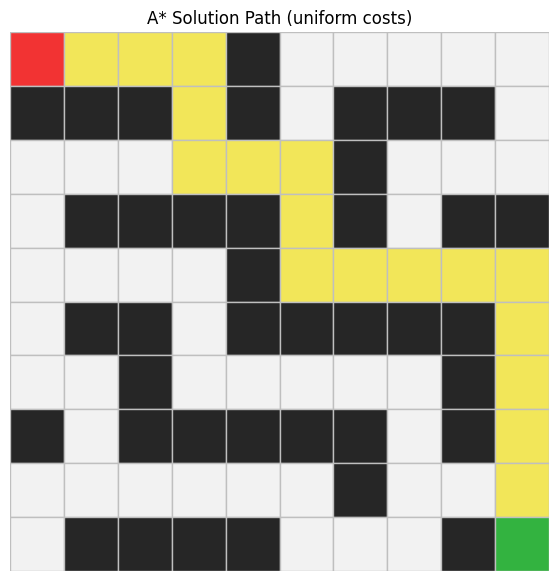

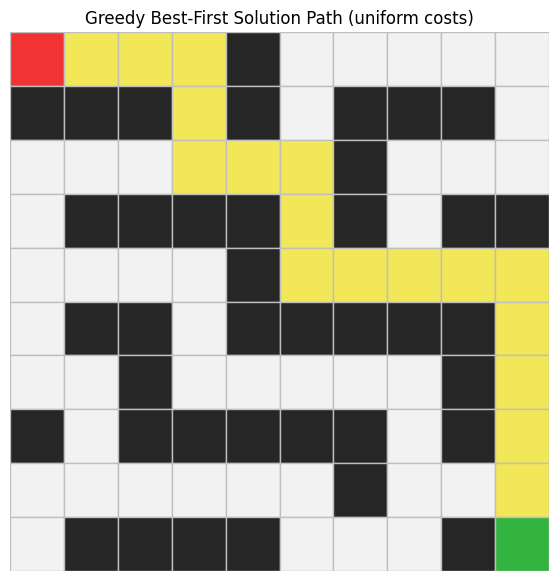

In [16]:
### 11. Run the Algorithms on the Part A Sample Map


sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)


# Visualize two solution paths on the uniform map.

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)

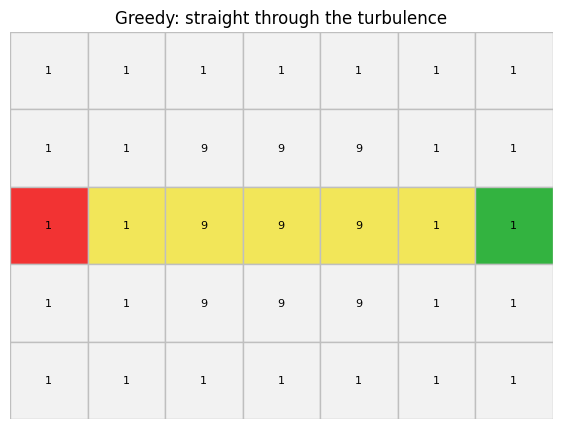

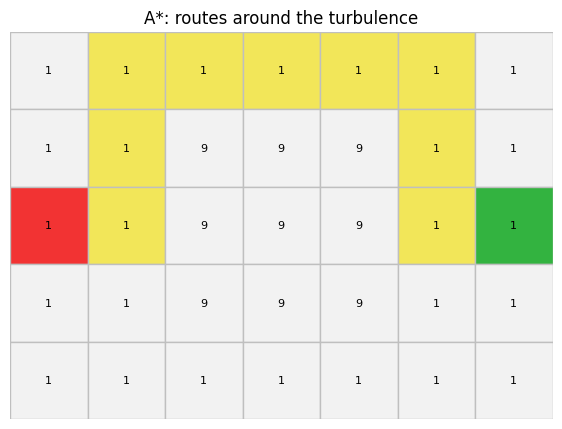

In [17]:
### 12. The Turbulence Map: Where Greedy Goes Wrong


turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)


# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

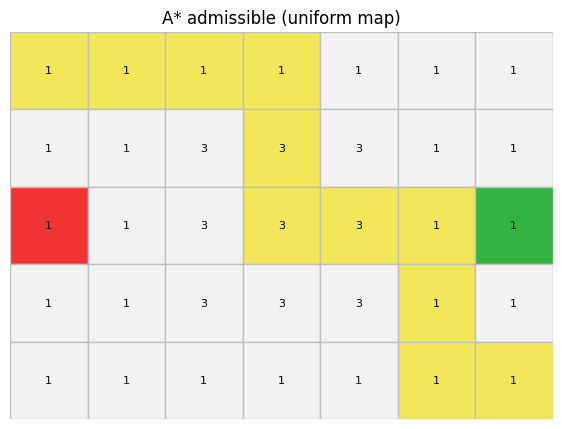

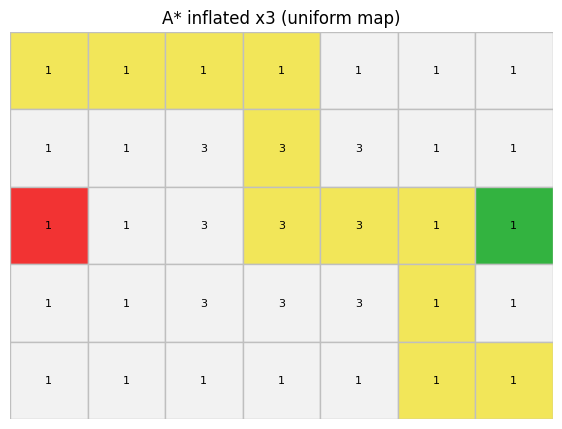

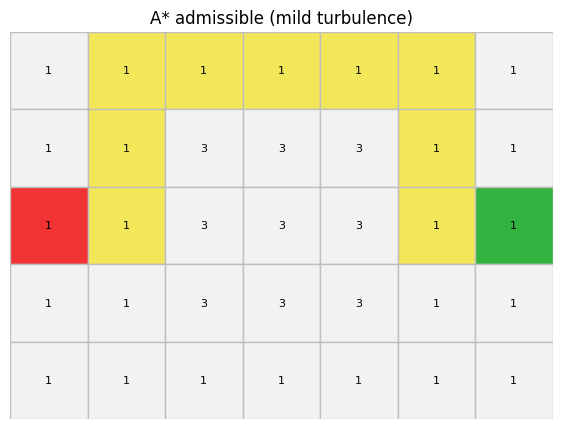

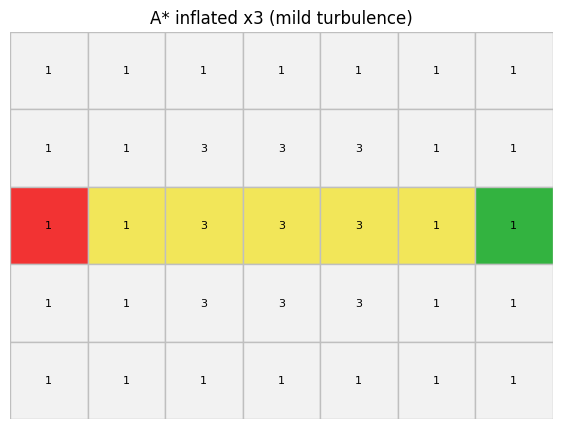

In [22]:
### 13. Experiment: Breaking Admissibility


def inflated_heuristic(factor: float):

    def h(state, g):
        return factor * manhattan_distance(state, g)

    return h

# Once TODO 8 is complete, run the comparison.
#
# The "mild turbulence" map below is designed to expose the inflated
# heuristic: the direct route through the cost-3 band costs 12, while the
# calm detour costs 10. An overconfident heuristic charges straight ahead.

mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

plot_path(
    mild_grid,
    mild_problem.start,
    mild_problem.goal,
    path=experiment_results[0].path,
    terrain_costs=mild_costs,
    title="A* admissible (uniform map)",
)

plot_path(
    mild_grid,
    mild_problem.start,
    mild_problem.goal,
    path=experiment_results[1].path,
    terrain_costs=mild_costs,
    title="A* inflated x3 (uniform map)",
)

plot_path(
    mild_grid,
    mild_problem.start,
    mild_problem.goal,
    path=experiment_results[2].path,
    terrain_costs=mild_costs,
    title="A* admissible (mild turbulence)",
)

plot_path(
    mild_grid,
    mild_problem.start,
    mild_problem.goal,
    path=experiment_results[3].path,
    terrain_costs=mild_costs,
    title="A* inflated x3 (mild turbulence)",
)

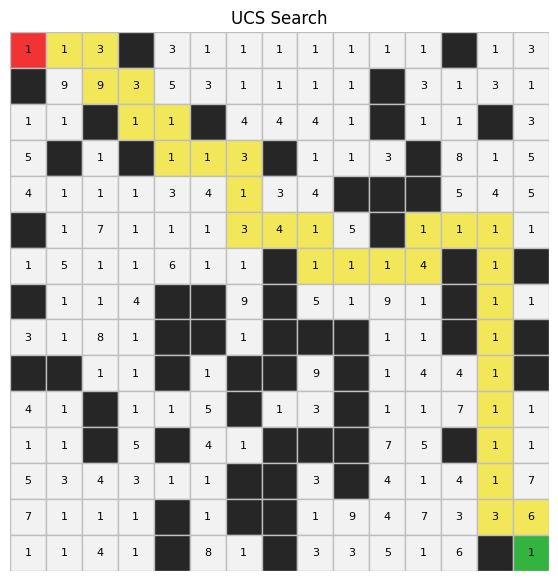

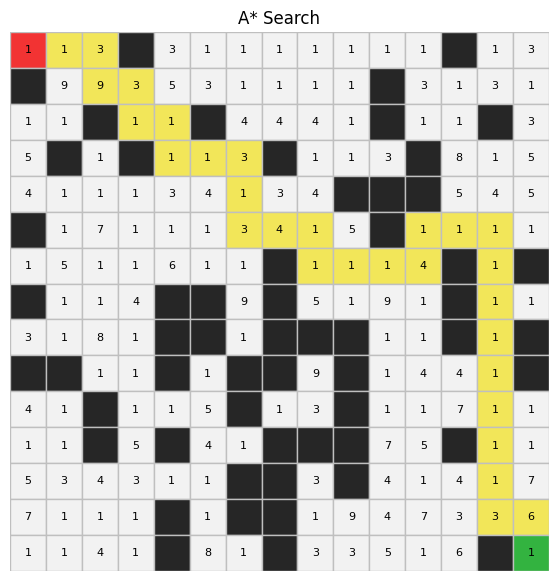

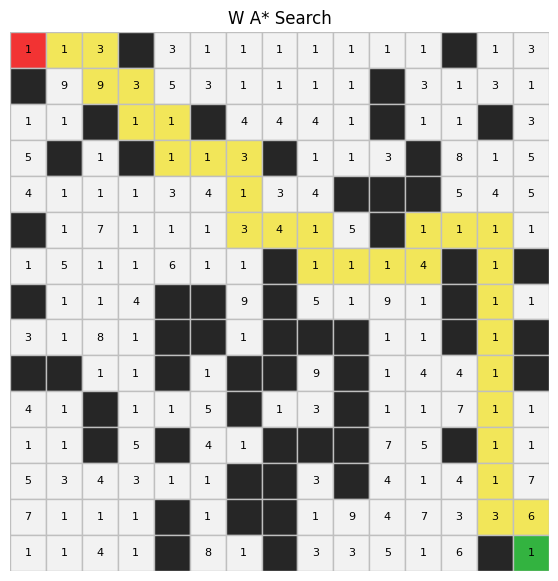

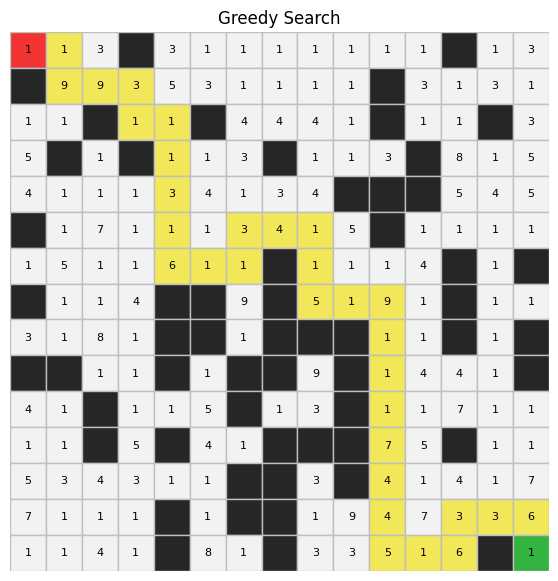

In [24]:
### 15. Create Your Own Maps



# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
[0,0,0,1,0,0,0,0,0,0,0,0,1,0,0],
[1,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
[0,0,1,0,0,1,0,0,0,0,1,0,0,1,0],
[0,1,0,1,0,0,0,1,0,0,0,1,0,0,0],
[0,0,0,0,0,0,0,0,0,1,1,1,0,0,0],
[1,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
[0,0,0,0,0,0,0,1,0,0,0,0,1,0,1],
[1,0,0,0,1,1,0,1,0,0,0,0,1,0,0],
[0,0,0,0,1,1,0,1,1,1,0,0,1,0,1],
[1,1,0,0,1,0,1,1,0,1,0,0,0,0,1],
[0,0,1,0,0,0,1,0,0,1,0,0,0,0,0],
[0,0,1,0,1,0,0,1,1,1,0,0,1,0,0],
[0,0,0,0,0,0,1,1,0,1,0,0,0,0,0],
[0,0,0,0,1,0,1,1,0,0,0,0,0,0,0],
[0,0,0,0,1,0,0,1,0,0,0,0,0,1,0],
]
custom_costs_1 = [
    [1,1,3,1,3,1,1,1,1,1,1,1,1,1,3],
[1,9,9,3,5,3,1,1,1,1,1,3,1,3,1],
[1,1,1,1,1,1,4,4,4,1,1,1,1,1,3],
[5,1,1,1,1,1,3,1,1,1,3,1,8,1,5],
[4,1,1,1,3,4,1,3,4,1,1,1,5,4,5],
[1,1,7,1,1,1,3,4,1,5,1,1,1,1,1],
[1,5,1,1,6,1,1,1,1,1,1,4,1,1,1],
[1,1,1,4,1,1,9,1,5,1,9,1,1,1,1],
[3,1,8,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,9,1,1,4,4,1,1],
[4,1,1,1,1,5,1,1,3,1,1,1,7,1,1],
[1,1,1,5,1,4,1,1,1,1,7,5,1,1,1],
[5,3,4,3,1,1,1,1,3,1,4,1,4,1,7],
[7,1,1,1,1,1,1,1,1,9,4,7,3,3,6],
[1,1,4,1,1,8,1,1,3,3,5,1,6,1,1],
]

custom_start_1 = (0, 0)
custom_goal_1 = (14, 14)

# Example after completing:
custom_problem_1 = WeightedGridProblem(
    custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
)
custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]
show_results(custom_results_1)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[0].path,
    terrain_costs=custom_costs_1,
    title="UCS Search",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[1].path,
    terrain_costs=custom_costs_1,
    title="A* Search",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[2].path,
    terrain_costs=custom_costs_1,
    title="W A* Search",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[3].path,
    terrain_costs=custom_costs_1,
    title="Greedy Search",
)

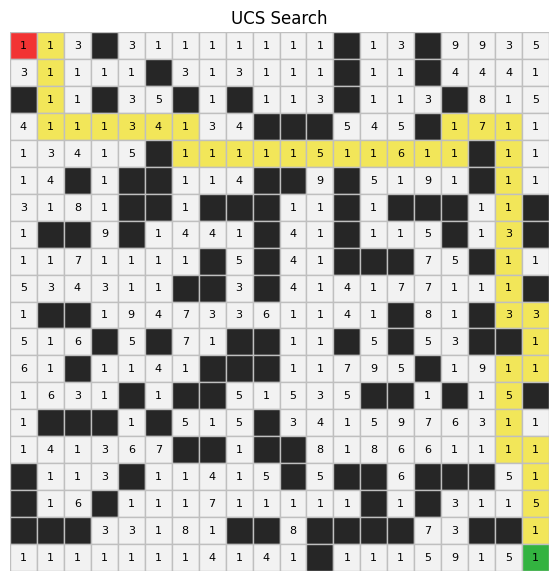

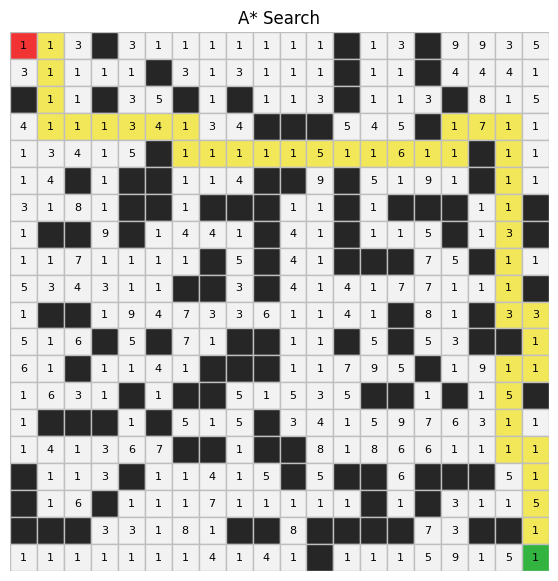

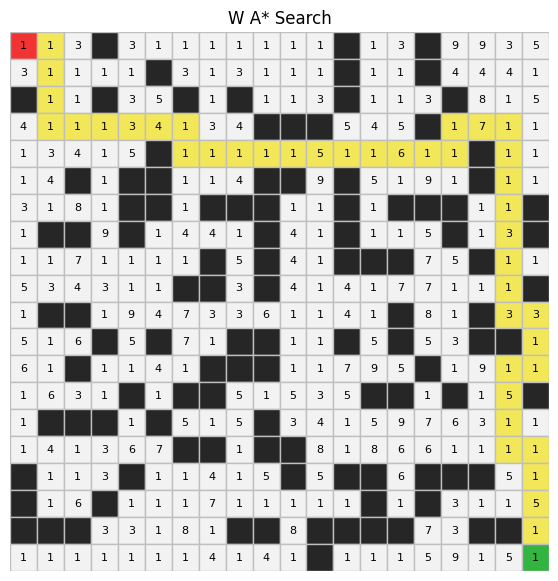

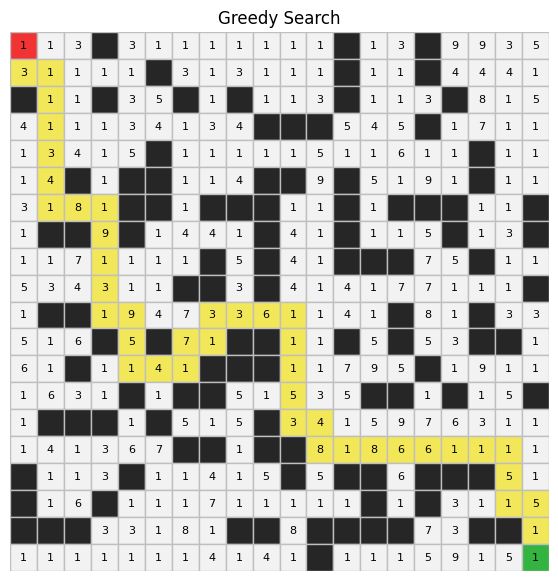

In [25]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
[0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0],
[0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0],
[1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0],
[0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,1,0,0,0,0],
[0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
[0,0,1,0,1,1,0,0,0,1,1,0,1,0,0,0,0,1,0,0],
[0,0,0,0,1,1,0,1,1,1,0,0,1,0,1,1,1,0,0,1],
[0,1,1,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1],
[0,0,0,0,0,0,0,1,0,1,0,0,1,1,1,0,0,1,0,0],
[0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,1],
[0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0],
[0,0,0,1,0,1,0,0,1,1,0,0,1,0,1,0,0,1,1,0],
[0,0,1,0,0,0,0,1,1,1,0,0,0,0,0,1,0,0,0,0],
[0,0,0,0,1,0,1,1,0,0,0,0,0,1,1,0,1,0,0,1],
[0,1,1,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
[0,0,0,0,0,0,1,1,0,1,1,0,0,0,0,0,0,0,0,0],
[1,0,0,0,1,0,0,0,0,0,1,0,1,1,0,1,1,1,0,0],
[1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0],
[1,1,1,0,0,0,0,0,1,1,0,1,1,1,1,0,0,1,1,0],
[0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],
]

custom_costs_2 = [
[1,1,3,1,3,1,1,1,1,1,1,1,1,1,3,1,9,9,3,5],
[3,1,1,1,1,1,3,1,3,1,1,1,1,1,1,1,4,4,4,1],
[1,1,1,1,3,5,1,1,1,1,1,3,1,1,1,3,1,8,1,5],
[4,1,1,1,3,4,1,3,4,1,1,1,5,4,5,1,1,7,1,1],
[1,3,4,1,5,1,1,1,1,1,1,5,1,1,6,1,1,1,1,1],
[1,4,1,1,1,1,1,1,4,1,1,9,1,5,1,9,1,1,1,1],
[3,1,8,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,9,1,1,4,4,1,1,4,1,1,1,1,5,1,1,3,1],
[1,1,7,1,1,1,1,1,5,1,4,1,1,1,1,7,5,1,1,1],
[5,3,4,3,1,1,1,1,3,1,4,1,4,1,7,7,1,1,1,1],
[1,1,1,1,9,4,7,3,3,6,1,1,4,1,1,8,1,1,3,3],
[5,1,6,1,5,1,7,1,1,1,1,1,1,5,1,5,3,1,1,1],
[6,1,1,1,1,4,1,1,1,1,1,1,7,9,5,1,1,9,1,1],
[1,6,3,1,1,1,1,1,5,1,5,3,5,1,1,1,1,1,5,1],
[1,1,1,1,1,1,5,1,5,1,3,4,1,5,9,7,6,3,1,1],
[1,4,1,3,6,7,1,1,1,1,1,8,1,8,6,6,1,1,1,1],
[1,1,1,3,1,1,1,4,1,5,1,5,1,1,6,1,1,1,5,1],
[1,1,6,1,1,1,1,7,1,1,1,1,1,1,1,1,3,1,1,5],
[1,1,1,3,3,1,8,1,1,1,8,1,1,1,1,7,3,1,1,1],
[1,1,1,1,1,1,1,4,1,4,1,1,1,1,1,5,9,1,5,1],
]

custom_start_2 = (0, 0)
custom_goal_2 = (19, 19)

# Example after completing:
custom_problem_2 = WeightedGridProblem(
    custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
)
custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
]
show_results(custom_results_2)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[0].path,
    terrain_costs=custom_costs_2,
    title="UCS Search",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[1].path,
    terrain_costs=custom_costs_2,
    title="A* Search",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[2].path,
    terrain_costs=custom_costs_2,
    title="W A* Search",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[3].path,
    terrain_costs=custom_costs_2,
    title="Greedy Search",
)

### 16. Reflection Questions



### 16.1 Heuristic Functions
- it estimates the cost to go from the current node to the goal, and it gets its domain knowledge from a formula on coordinates, being the geometry.
- In a relaxed problem, the drone can fly through walls and every move costs the same
- Manhattan dominates Euclidean on this grid because it's just 4 dimension, in the sense that Euclidean is for length between 2 cells, and if our points are diagonal, that won't work cause we can't move diagonally. On the other hand, this same domination predicts that Manhattan-guided A* expands fewer nodes.
- The reason why terrain costs can't deep below 1 is because Manhattan distance is saying under the hood that every step is at least 1, or more. And so if it falls below that to 0.5, the heuristic will overshoot the prediction.



### 16.2 Greedy Best-First Search
- Greedy only looks at h(n), it has completely forgotten what it already spent to get here. When you drop it on the turbulence map, it'll move straight through a wind corridor because the goal "looks closer", without actually looking at the fact that the actual bill just tripled.
- Fewer expansions doesn't make it better, its either it's cheap and fast, but nothing stops it from handing you a worse path.
- A drone mission where greedy is fine would be anything where getting to the goal matters more than the cost of getting there, so like probably an emergency visual check, where you just need eyes on target immediately.



### 16.3 A* Search
- `f(n) = g(n) + h(n)` is basically the distance i've already traveled, plus my best guess at what's left to go. Add them, and you get an estimate of the whole trip's cost.
- A* checks for the goal rather when popping a node because a node's cost can still drop before it's popped, in the sense that you can still get something cheaper. If you test early on the turbulence map, you risk locking in a path before you've actually seen the cheap route.
- `reached` has to be a dictionary because the same cell can be reached more than once at different costs now. The set would only tell you whether its 'seen' or  'not seen'. You'll also need to know how cheap the paths are.
- The` UCS-vs-A*` expansion gap is basically a measure of how much the heuristic is doing for you. UCS has no heuristics in the sense that every direction is even. A* gets steered by the heuristics, so it explores way less of the map to find that same answer.



### 16.4 Admissibility and Consistency
- Admissibility simply means that the heuristics never overestimates the real cost, whilst consistency means hte heuristics can't drop by more than the actual step cost while you're moving. Consistency implies admissibility, because it's stricter.



### 16.5 Weighted A* and Trade-offs





### 16.6 Memory and Real-World Drone Context


